# Variational Autoencoder (VAE) Training on MNIST

This notebook implements and trains a Variational Autoencoder on the MNIST dataset.

## 1. Imports and Dependencies

In [14]:
from torch import nn
from abc import abstractmethod
from PIL import Image
from typing import List, Any, TypeVar
import torch
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms, utils
from torch.optim import Adam, lr_scheduler
from tqdm import tqdm
import os
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

Tensor = TypeVar("torch.tensor")

## 2. Model Architecture

Define the base VAE class and the Vanilla VAE implementation.

In [4]:
class BaseVAE(nn.Module):

    def __init__(self) -> None:
        super(BaseVAE, self).__init__()

    def encode(self, input: Tensor) -> List[Tensor]:
        raise NotImplementedError

    def decode(self, input: Tensor) -> Any:
        raise NotImplementedError

    def sample(self, batch_size: int, current_device: int, **kwargs) -> Tensor:
        raise NotImplementedError

    def generate(self, x: Tensor, **kwargs) -> Tensor:
        raise NotImplementedError

    @abstractmethod
    def forward(self, *inputs: Tensor) -> Tensor:
        pass

    @abstractmethod
    def loss_function(self, *inputs: Any, **kwargs) -> Tensor:
        pass

In [5]:
class VanillaVAE(BaseVAE):

    def __init__(
        self, in_channels: int, latent_dim: int, hidden_dims: List = None, **kwargs
    ) -> None:
        super(VanillaVAE, self).__init__()

        self.latent_dim = latent_dim

        modules = []
        if hidden_dims is None:
            hidden_dims = [32, 64, 128]

        # Build Encoder
        for h_dim in hidden_dims:
            modules.append(
                nn.Sequential(
                    nn.Conv2d(
                        in_channels,
                        out_channels=h_dim,
                        kernel_size=3,
                        stride=2,
                        padding=1,
                    ),
                    nn.BatchNorm2d(h_dim),
                    nn.LeakyReLU(),
                )
            )
            in_channels = h_dim

        self.encoder = nn.Sequential(*modules)
        self.fc_mu = nn.Linear(hidden_dims[-1] * 4 * 4, latent_dim)
        self.fc_var = nn.Linear(hidden_dims[-1] * 4 * 4, latent_dim)

        # Build Decoder
        modules = []

        self.decoder_input = nn.Linear(latent_dim, hidden_dims[-1] * 4 * 4)

        hidden_dims.reverse()

        for i in range(len(hidden_dims) - 1):
            modules.append(
                nn.Sequential(
                    nn.ConvTranspose2d(
                        hidden_dims[i],
                        hidden_dims[i + 1],
                        kernel_size=3,
                        stride=2,
                        padding=1,
                        output_padding=1,
                    ),
                    nn.BatchNorm2d(hidden_dims[i + 1]),
                    nn.LeakyReLU(),
                )
            )

        self.decoder = nn.Sequential(*modules)

        self.final_layer = nn.Sequential(
            nn.ConvTranspose2d(
                hidden_dims[-1],
                hidden_dims[-1],
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1,
            ),
            nn.BatchNorm2d(hidden_dims[-1]),
            nn.LeakyReLU(),
            nn.Conv2d(hidden_dims[-1], out_channels=1, kernel_size=3, padding=1),
            nn.Sigmoid(),
        )

    def encode(self, input: Tensor) -> List[Tensor]:
        result = self.encoder(input)
        result = torch.flatten(result, start_dim=1)

        mu = self.fc_mu(result)
        log_var = self.fc_var(result)

        return [mu, log_var]

    def decode(self, z: Tensor) -> Tensor:
        result = self.decoder_input(z)
        result = result.view(-1, 128, 4, 4)
        result = self.decoder(result)
        result = self.final_layer(result)
        return result

    def reparameterize(self, mu: Tensor, logvar: Tensor) -> Tensor:
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return eps * std + mu

    def forward(self, input: Tensor, **kwargs) -> List[Tensor]:
        mu, log_var = self.encode(input)
        z = self.reparameterize(mu, log_var)
        return [self.decode(z), input, mu, log_var]

    def loss_function(self, *args, **kwargs) -> dict:
        recons = args[0]
        input = args[1]
        mu = args[2]
        log_var = args[3]

        kld_weight = kwargs["M_N"]  # Account for the minibatch samples from the dataset
        recons_loss = F.mse_loss(recons, input)

        kld_loss = torch.mean(
            -0.5 * torch.sum(1 + log_var - mu**2 - log_var.exp(), dim=1), dim=0
        )

        loss = recons_loss + kld_weight * kld_loss
        return {
            "loss": loss,
            "Reconstruction_Loss": recons_loss.detach(),
            "KLD": -kld_loss.detach(),
        }

    def sample(self, num_samples: int, current_device: int, **kwargs) -> Tensor:
        z = torch.randn(num_samples, self.latent_dim)
        z = z.to(current_device)
        samples = self.decode(z)
        return samples

    def generate(self, x: Tensor, **kwargs) -> Tensor:
        return self.forward(x)[0]

## 3. Configuration and Setup

Define hyperparameters and create necessary directories.

In [6]:
# Define paths
weights_dir = "./weights/"
results_dir = "./results/"
recons_dir = results_dir + "reconstructions/"
samples = results_dir + "samples/"
log_dir = "./logs/"
latents_dir = "./latents/"

# Create directories if not exist
os.makedirs(weights_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)
os.makedirs(latents_dir, exist_ok=True)
os.makedirs(recons_dir, exist_ok=True)

# Hyperparameters
batch_size = 512
learning_rate = 0.001
weight_decay = 0.0
scheduler_gamma = 0.95
num_epochs = 30
latent_dim = 20
img_size = 28
kld_weight = 0.00025  # weight of KL divergence in the loss

# Number of images to embed
num_images = 5000
    
torch.manual_seed(42)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 4. Data Loading

Load and prepare the MNIST dataset with train/validation splits.

In [7]:
# Transformations
transform = transforms.Compose(
    [
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
    ]
)

# Load dataset
dataset = datasets.MNIST(root="./data", train=True, transform=transform, download=True)

# Split dataset into train and validation sets
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Data loaders
train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=4
)
val_loader = DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False, num_workers=2
)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Training samples: 54000
Validation samples: 6000


## 5. Model Initialization

Initialize the VAE model and optimizer.

In [9]:
# Initialize model and optimizer
model = VanillaVAE(in_channels=1, latent_dim=latent_dim).to(device)
optimizer = Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Lists to store losses for plotting
recon_losses = []
kl_losses = []

print("Model initialized successfully!")

Model initialized successfully!


## 6. Training Loop

Train the VAE model on the MNIST dataset.

In [10]:
# Training loop
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images, _ = batch
        images = images.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss_dict = model.loss_function(*outputs, M_N=kld_weight)
        loss = loss_dict["loss"]
        loss.backward()
        optimizer.step()

        train_loss += loss.item()   
        recon_losses.append(loss_dict["Reconstruction_Loss"].item())
        kl_losses.append(loss_dict["KLD"].item())

    avg_train_loss = train_loss / len(train_loader)

    # Validation loop
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            images, _ = batch
            images = images.to(device)

            outputs = model(images)
            loss_dict = model.loss_function(*outputs, M_N=kld_weight)
            val_loss += loss_dict["loss"].item()

    avg_val_loss = val_loss / len(val_loader)

    if (epoch+1) % 10 == 0:
        # Save model checkpoint
        torch.save(
            model.state_dict(), os.path.join(weights_dir, f"vae_epoch_{epoch+1}.pth")
        )

    print(
        f"Epoch [{epoch+1}/{num_epochs}], "
        f"Train Loss: {avg_train_loss:.4f}, "
        f"Validation Loss: {avg_val_loss:.4f}, "
        f"Recon Loss: {loss_dict['Reconstruction_Loss']:.4f}, "
        f"KLD: {loss_dict['KLD']:.4f}"
    )

Epoch 1/30: 100%|██████████| 106/106 [00:03<00:00, 33.11it/s]


Epoch [1/30], Train Loss: 0.0428, Validation Loss: 0.0197, Recon Loss: 0.0125, KLD: -28.7171


Epoch 2/30: 100%|██████████| 106/106 [00:02<00:00, 42.01it/s]


Epoch [2/30], Train Loss: 0.0178, Validation Loss: 0.0167, Recon Loss: 0.0094, KLD: -28.7960


Epoch 3/30: 100%|██████████| 106/106 [00:02<00:00, 42.45it/s]


...

Epoch [28/30], Train Loss: 0.0132, Validation Loss: 0.0133, Recon Loss: 0.0064, KLD: -27.6601


Epoch 29/30: 100%|██████████| 106/106 [00:02<00:00, 41.89it/s]


Epoch [29/30], Train Loss: 0.0132, Validation Loss: 0.0133, Recon Loss: 0.0063, KLD: -27.6835


Epoch 30/30: 100%|██████████| 106/106 [00:02<00:00, 41.53it/s]


Epoch [30/30], Train Loss: 0.0131, Validation Loss: 0.0133, Recon Loss: 0.0061, KLD: -27.9053


## 7. Generate and Save Embeddings

Extract latent representations from the validation set.

In [11]:
# Generate and save embeddings
latent_codes = []

model.eval()

# Loop through the first num_images images in the validation set
with torch.no_grad():
    for i in range(num_images):
        image, _ = val_dataset[i]
        image = image.unsqueeze(0).to(device)
        
        # Obtain the latent code and flatten it
        latent_code = model.encode(image)[0].cpu().numpy().flatten()
        latent_codes.append(latent_code)
        
np.save(latents_dir + "latent_codes_final.npy", latent_codes)
        
labels = []
for i in range(0, num_images):
    labels.append(val_dataset[i][1])

np.save(latents_dir + "labels.npy", labels)
np.save(latents_dir + "recon_losses_full.npy", recon_losses)
np.save(latents_dir + "kl_losses_full.npy", kl_losses)

print(f"Saved {len(latent_codes)} latent codes and labels")

Saved 5000 latent codes and labels


## 8. Visualization

Visualize original images and their reconstructions.

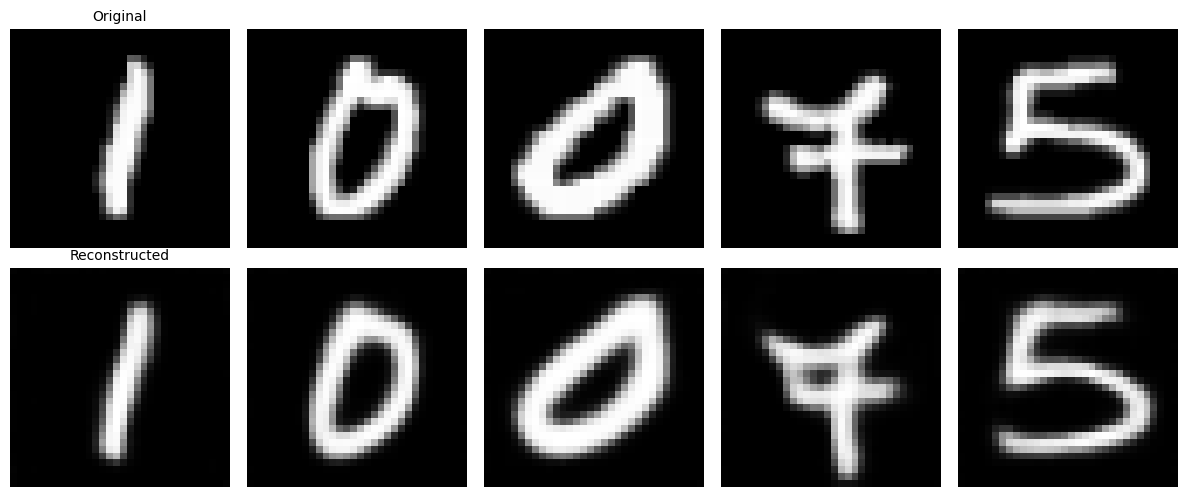

Saved 5 original and reconstructed images to ./results/reconstructions/


In [12]:
# Visualize reconstructions for a few samples
num_samples = 5

fig, axes = plt.subplots(2, num_samples, figsize=(12, 5))

for i in range(num_samples):
    img = val_dataset[i][0].unsqueeze(0).to(device)
    output = model(img)[0]
    
    # Original image
    original = img.squeeze().detach().cpu().numpy()
    axes[0, i].imshow(original, cmap="gray")
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title("Original", fontsize=10)
    
    # Reconstructed image
    reconstructed = output.squeeze().detach().cpu().numpy()
    axes[1, i].imshow(reconstructed, cmap="gray")
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title("Reconstructed", fontsize=10)
    
    # Save individual images
    plt.imsave(f"{recons_dir}original_{i}.png", original, cmap="gray")
    plt.imsave(f"{recons_dir}reconstructed_{i}.png", reconstructed, cmap="gray")

plt.tight_layout()
plt.show()

print(f"Saved {num_samples} original and reconstructed images to {recons_dir}")

## 9. Homework: Latent Space Interpolation

**Task**: Implement latent space interpolation to visualize smooth transitions between two different digit images.

**Objectives**:
- Select two images from the training dataset
- Encode both images to obtain their latent representations
- Perform linear interpolation between the latent codes
- Decode the interpolated latent codes to generate intermediate images
- Save and visualize the interpolation sequence

**Expected Outcome**: You should observe a smooth morphing transition between the two selected digits, demonstrating that the VAE has learned a continuous latent space representation.

**Instructions**: Run the code below to generate interpolated images. Try changing the `idx` variable to interpolate between different pairs of digits!

Saved 64 interpolated images to ./interpolations/


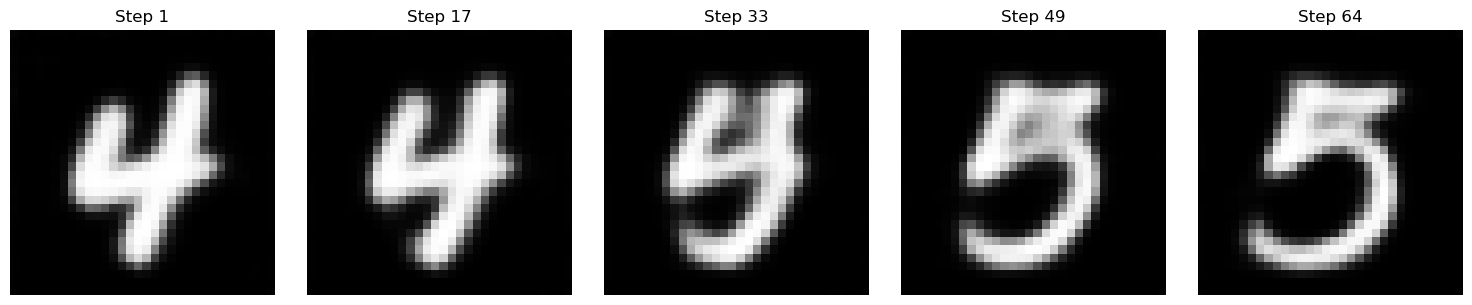